In [28]:
## Load packages
from costs_benefits_ssp.cb_calculate import CostBenefits
import pandas as pd
from costs_benefits_ssp.model.cb_data_model import TXTable,CostFactor,TransformationCost,StrategyInteraction
import polars as pl
import os

In [ ]:
##---- Define Directories ----##
SCRIPT_DIR_PATH = os.getcwd()
PARENT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
OUTPUT_CB_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "cb_config_files")
RUN_OUTPUT_DIR_PATH = os.path.join(PARENT_DIR_PATH, "ssp_run_output")

# REGULAR RUN
# RUN_ID = "sisepuede_results_sisepuede_run_2026-01-28T17;21;42.513991"
RUN_ID = "sisepuede_results_sisepuede_run_2026-01-29T17;21;21.398032"

# TORNADO RUN
# RUN_ID = "sisepuede_results_sisepuede_run_2026-01-28T15;11;38.217551"

# TRWW DEBUG RUN_ID
# RUN_ID = "sisepuede_results_sisepuede_run_2026-01-29T15;28;40.322709"

RUN_DIR_PATH = os.path.join(RUN_OUTPUT_DIR_PATH, RUN_ID)


In [30]:
# Make sure output directory exists
os.makedirs(OUTPUT_CB_PATH, exist_ok=True)

In [31]:
## Load the data
ssp_data = pd.read_csv(os.path.join(RUN_DIR_PATH, 
                                    "decomposed_ssp_output.csv"))
att_primary = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
att_strategy = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_STRATEGY.csv"))
print(f"Loaded ssp_data with {ssp_data.shape[0]} rows and {ssp_data.shape[1]} columns")
print(f"Loaded att_primary with {att_primary.shape[0]} rows and {att_primary.shape[1]} columns")
print(f"Loaded att_strategy with {att_strategy.shape[0]} rows and {att_strategy.shape[1]} columns")

Loaded ssp_data with 145 rows and 4054 columns
Loaded att_primary with 5 rows and 4 columns
Loaded att_strategy with 126 rows and 6 columns


In [32]:
ssp_data.head()

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha,yf_lndu_supremum_pastures_tonne_per_ha
0,0,bulgaria,7,0,1.869757e+06,4493.247016,76487.740236,40316.177137,7558.127764,2.367448e+06,...,1.011737,0.509224,2.194576,0.5,1.937249,6.079400,55.765409,18.800200,2.759238,92.81
1,0,bulgaria,8,0,1.867011e+06,4486.648517,76375.415182,40256.971351,7547.028376,2.363971e+06,...,1.011737,0.380228,3.079152,0.5,1.578307,5.689031,55.765409,21.599397,2.875868,92.81
2,0,bulgaria,9,0,1.864295e+06,4480.119826,76264.278438,40198.391916,7536.046410,2.360531e+06,...,1.011737,0.380228,3.079152,0.5,1.578307,5.689031,55.765409,21.599397,2.875868,92.81
3,0,bulgaria,10,0,1.861622e+06,4473.697057,76154.944782,40140.762876,7525.242617,2.357147e+06,...,1.011737,0.380228,3.079152,0.5,1.578307,5.689031,55.765409,21.599397,2.875868,92.81
4,0,bulgaria,11,0,1.858993e+06,4467.379389,76047.400257,40084.076875,7514.615616,2.353819e+06,...,1.011737,0.380228,3.079152,0.5,1.578307,5.689031,55.765409,21.599397,2.875868,92.81


In [33]:
att_strategy.head()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0


In [34]:
att_strategy.tail()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
121,6055,PFLO:WALI_BIOGAS_ACTIONS_WAM,Singleton - WAM Value - PFLO: WALI actions to...,NaN,TX:TRWW:INC_CAPTURE_BIOGAS_STRATEGY_WAM|TX:WAL...,0
122,6066,WALI:INC_TREATMENT_RURAL_WAM,Singleton - WAM Value - WALI: Improved rural w...,NaN,TX:WALI:INC_TREATMENT_RURAL_STRATEGY_WAM,0
123,6067,WALI:INC_TREATMENT_URBAN_WAM,Singleton - WAM Value - WALI: Improved urban w...,NaN,TX:WALI:INC_TREATMENT_URBAN_STRATEGY_WAM,0
124,6056,PFLO:BAU,BAU,Business as Usual,TX:TRWW:INC_CAPTURE_BIOGAS_STRATEGY_BAU|TX:WAL...,0
125,6057,PFLO:WAM_F,WAM_F,With Additional Measures and Forestry,TX:ENTC:TARGET_RENEWABLE_ELEC_STRATEGY_WAM_F|T...,0


In [35]:
att_primary

,primary_id,design_id,strategy_id,future_id
0,0,0,0,0
1,74074,0,6003,0
2,75075,0,6004,0
3,122122,0,6056,0
4,123123,0,6057,0


In [36]:
# Check for empty transformation_specification in att_strategy
mask_empty = att_strategy["transformation_specification"].isna() | (att_strategy["transformation_specification"].str.strip() == "")
if mask_empty.any():
    print("Warning: strategies with empty transformation_specification:", 
          att_strategy.loc[mask_empty, "strategy_code"].tolist())

In [37]:
## Define base strategy
# strategy_code_base = "PFLO:BAU"
strategy_code_base = "BASE"

In [38]:
# Check if strategy_code_base exists in att_strategy
if strategy_code_base not in att_strategy['strategy_code'].values:
    raise ValueError(f"Base strategy code '{strategy_code_base}' not found in att_strategy.")

### Some mods needed for cb to work propely

**Dec cement clinker**

In [39]:
# Create a new field for clinker
ssp_data["prod_ippu_clinker_tonne"] = ssp_data["prod_ippu_cement_tonne"] * ssp_data["frac_ippu_cement_clinker"]
ssp_data["prod_ippu_clinker_tonne"]

0      1.830433e+06
1      1.834396e+06
2      1.852522e+06
3      1.867148e+06
4      1.880962e+06
           ...     
140    1.465936e+06
141    1.439507e+06
142    1.412952e+06
143    1.386134e+06
144    1.358954e+06
Name: prod_ippu_clinker_tonne, Length: 145, dtype: float64

**hfc fix**

In [40]:
ef_hfc_fields = [col for col in ssp_data.columns if "ef_ippu_tonne_ch" in col and "electronics" in col]
ef_hfc_fields

['ef_ippu_tonne_ch2f2_per_tonne_production_electronics',
 'ef_ippu_tonne_ch3f_per_tonne_production_electronics',
 'ef_ippu_tonne_chf3_per_tonne_production_electronics']

In [41]:
# Create a new ef field for HFCs
ssp_data["ef_ippu_tonne_hfc_per_tonne_production_electronics"] = ssp_data[ef_hfc_fields].sum(axis=1)
ssp_data["ef_ippu_tonne_hfc_per_tonne_production_electronics"]

0      9.279917e-04
1      8.981633e-04
2      8.683350e-04
3      8.385066e-04
4      8.086782e-04
           ...     
140    3.038138e-05
141    1.961335e-05
142    1.097590e-05
143    4.469055e-06
144    9.280737e-08
Name: ef_ippu_tonne_hfc_per_tonne_production_electronics, Length: 145, dtype: float64

### Continue with the CB standard process

In [42]:
## Instantiate an object of the CostBenefits class
cb = CostBenefits(ssp_data, att_primary, att_strategy, strategy_code_base)

The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTr

In [43]:
# Once the excel file has been updated, we can reload it to update the cost factors database
cb.load_cb_parameters(os.path.join(CONFIG_DIR_PATH, "cb_config_params.xlsx"))

Cargamos configuración de archivo excel
Se actualizó la base de datos


In [44]:
# Compute System Costs
results_system = cb.compute_system_cost_for_all_strategies(verbose=False)


************************************
*Strategy : PFLO:WEM (0/4)
************************************


************************************
*Strategy : PFLO:WAM (1/4)
************************************


************************************
*Strategy : PFLO:BAU (2/4)
************************************


************************************
*Strategy : PFLO:WAM_F (3/4)
************************************



In [45]:
# Compute Technical Costs
results_tx = cb.compute_technical_cost_for_all_strategies(verbose=False)


************************************
*Strategy : PFLO:WEM (0/4)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost


####################################################################################################
[DEBUG] ENTER cb_ippu_clinker
[DEBUG] strategy_base: BASE
[DEBUG] strategy_tx: PFLO:WEM
[DEBUG] diff_var: prod_ippu_clinker_tonne
[DEBUG] output_variable_name: cb:i

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:856: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["difference_variable"] = cb_orm.diff_var
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:857: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["difference_value"] = data_merged["difference"]
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:858: SettingWithCopyWarning: 
A va

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost


##############################################################################################################
[DEBUG] ENTER cb_fraction_change
[DEBUG] strategy_base: BASE
[DEBUG] strategy_tx: PFLO:WAM
[DEBUG] frac_var (arg1): fuelefficiency_trns_road_light_gasoline_km_per_litr

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:856: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["difference_variable"] = cb_orm.diff_var
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:857: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["difference_value"] = data_merged["difference"]
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:858: SettingWithCopyWarning: 
A va


[DEBUG] output_tx (effect variable)
shape: (29, 7)
     region  time_period                                   variable  value
0  bulgaria            7  emission_co2e_n2o_ippu_production_plastic      0
1  bulgaria            8  emission_co2e_n2o_ippu_production_plastic      0
2  bulgaria            9  emission_co2e_n2o_ippu_production_plastic      0
3  bulgaria           10  emission_co2e_n2o_ippu_production_plastic      0
4  bulgaria           11  emission_co2e_n2o_ippu_production_plastic      0

------------------------------------------------------------------------------------------
[DEBUG] output_tx effect value stats
count    29.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: value, dtype: float64
[DEBUG] unique sample: [0]
[DEBUG] merged with output_tx shape: (29, 18)
[DEBUG] NaNs in effect value: 0

[DEBUG] data_merged after adding effect_value
shape: (29, 18)
     region  time_period  effect_value  fraction_multiplier
0

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1074: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_merged_results["variable_value_baseline"] = 0
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1075: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_merged_results["variable_value_pathway"] = data_merged["difference_value"]



************************************
*Strategy : PFLO:BAU (2/4)
************************************

The Strategy PFLO:BAU hasn't technical costs

************************************
*Strategy : PFLO:WAM_F (3/4)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Tr

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:856: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["difference_variable"] = cb_orm.diff_var
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:857: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["difference_value"] = data_merged["difference"]
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:858: SettingWithCopyWarning: 
A va

[DEBUG] Using self.ssp_data -> shape: (145, 4066)

[DEBUG] fraction_tx
shape: (29, 7)
     region  time_period                                           variable  \
0  bulgaria            7  ef_ippu_tonne_n2o_per_tonne_production_electro...   
1  bulgaria            8  ef_ippu_tonne_n2o_per_tonne_production_electro...   
2  bulgaria            9  ef_ippu_tonne_n2o_per_tonne_production_electro...   
3  bulgaria           10  ef_ippu_tonne_n2o_per_tonne_production_electro...   
4  bulgaria           11  ef_ippu_tonne_n2o_per_tonne_production_electro...   

      value  
0  0.000700  
1  0.000653  
2  0.000608  
3  0.000565  
4  0.000523  

[DEBUG] fraction_base
shape: (29, 7)
     region  time_period                                           variable  \
0  bulgaria            7  ef_ippu_tonne_n2o_per_tonne_production_electro...   
1  bulgaria            8  ef_ippu_tonne_n2o_per_tonne_production_electro...   
2  bulgaria            9  ef_ippu_tonne_n2o_per_tonne_production_electro...   
3

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1074: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_merged_results["variable_value_baseline"] = 0
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1075: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_merged_results["variable_value_pathway"] = data_merged["difference_value"]
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.p

In [46]:
# Combine results
results_all = pd.concat([results_system, results_tx], ignore_index = True)

In [47]:
#-------------POST PROCESS SIMULATION RESULTS---------------
# Post process interactions among strategies that affect the same variables
results_all_pp = cb.cb_process_interactions(results_all)

# SHIFT any stray costs incurred from 2015 to 2025 to 2025 and 2035
results_all_pp_shifted = cb.cb_shift_costs(results_all_pp)


Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:SHIFT_FUEL_HEAT, TX:SCOE:SHIFT_FUEL_HEAT 
Resolving Interactions in INEN : TX:INEN:INC_EFFICIENCY_ENERGY 
Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:SHIFT_FUEL_HEAT, TX:SCOE:SHIFT_FUEL_HEAT, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:INC_EFFICIENCY_ENERGY 
Resolving Interactions in SCOE :  
No interactions, skipping... PFLO:BAU
Resolving Interactions in INEN :  
No interactions, skipping... PFLO:BAU
Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:SHIFT_FUEL_HEAT, TX:SCOE:SHIFT_FUEL_HEAT, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUE

/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:660: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_pre2025["variable"] = res_pre2025["variable"] + "_shifted" + (res_pre2025["time_period"]+SSP_GLOBAL_TIME_PERIOD_0).astype(str)#create a new variable so they can be recognized as shifted costs
/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:661: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_pre2025["time_period"] =

In [48]:
results_all_pp_shifted

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,PFLO:WEM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
1,PFLO:WEM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
2,PFLO:WEM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
3,PFLO:WEM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0
4,PFLO:WEM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0
...,...,...,...,...,...,...,...,...,...,...
28155,PFLO:WAM_F,0.0,bulgaria,18.0,energy_consumption_inen_total,120.874119,120.874119,0.0,cb:inen:technical_savings:fuel_switch:all_shif...,-0.0
28156,PFLO:WAM_F,0.0,bulgaria,19.0,energy_consumption_inen_total,121.983142,121.983142,0.0,cb:inen:technical_savings:fuel_switch:all_shif...,-0.0
28157,PFLO:WAM_F,0.0,bulgaria,17.0,energy_consumption_inen_total,142.723230,142.723230,0.0,cb:inen:technical_cost:efficiency:X_shifted2022.0,0.0
28158,PFLO:WAM_F,0.0,bulgaria,18.0,energy_consumption_inen_total,143.218898,143.218898,0.0,cb:inen:technical_cost:efficiency:X_shifted2023.0,0.0


In [49]:
results_all_pp_shifted.strategy_code.unique()

array(['PFLO:WEM', 'PFLO:WAM', 'PFLO:BAU', 'PFLO:WAM_F'], dtype=object)

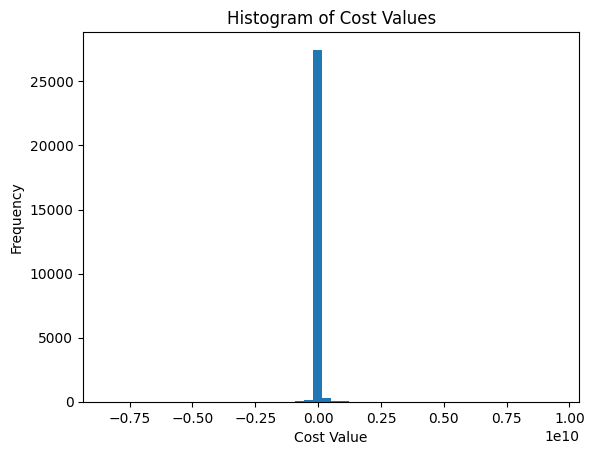

In [50]:
import matplotlib.pyplot as plt
plt.hist(results_all_pp_shifted.value, bins=50)
plt.title('Histogram of Cost Values')
plt.xlabel('Cost Value')
plt.ylabel('Frequency')
plt.show()

## Check for NaNs and Infs and DF Cleaning

In [51]:
# check nans
results_all_pp_shifted.value.isna().any()

np.False_

In [52]:
# check -inf or inf values
results_all_pp_shifted.value.isin([float('inf'), float('-inf')]).any()

np.False_

In [53]:
results_all_pp_shifted.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,PFLO:WEM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
1,PFLO:WEM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
2,PFLO:WEM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0
3,PFLO:WEM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0
4,PFLO:WEM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0


In [54]:
# results_all_pp_shifted.to_csv(os.path.join(OUTPUT_CB_PATH, f"costs_benefits_{RUN_ID}_tornado_raw.csv"), index=False)

## Reshape to load into tableau

In [55]:
# --- Read cost-benefit data ---
cb_data = results_all_pp_shifted.copy()

# Split 'variable' into components: name, sector, cb_type, item_1, item_2
# (Assumes exactly 5 colon-separated parts; if there are more colons inside the last field,
# they will be kept in item_2 thanks to n=4)
cb_chars = cb_data["variable"].astype(str).str.split(":", n=4, expand=True)
cb_chars.columns = ["name", "sector", "cb_type", "item_1", "item_2"]
cb_data = pd.concat([cb_data, cb_chars], axis=1)

In [56]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2
0,PFLO:WEM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural
1,PFLO:WEM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural
2,PFLO:WEM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural
3,PFLO:WEM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0,cb,wali,technical_cost,sanitation,unimp_rural
4,PFLO:WEM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0,cb,wali,technical_cost,sanitation,unimp_rural


In [57]:
# Scale value from USD to billions (divide by 1e9)
if "value" in cb_data.columns:
    cb_data["value"] = cb_data["value"] / 1e9

# --- Remove "shifted" entries ---
# Remove rows where item_2 contains "shifted"
cb_data = cb_data[~cb_data["item_2"].astype(str).str.contains("shifted", na=False)]

# Remove any remaining rows where variable contains "shifted2"
cb_data = cb_data[~cb_data["variable"].astype(str).str.contains("shifted2", na=False)]

# --- Add Year column (Year = time_period + 2015) ---
cb_data["Year"] = cb_data["time_period"] + 2015

**This Section Needs Manual Tunnning**

In [58]:
cb_data.strategy_code.unique()

array(['PFLO:WEM', 'PFLO:WAM', 'PFLO:BAU', 'PFLO:WAM_F'], dtype=object)

In [59]:
# Harmonize strategy name changes with a single mapping (no duplicate replacements)
strategy_name_map = {
    "PFLO:WEM": "With Existing Measures",
    "PFLO:WAM": "With Additional Measures",
    "PFLO:WAM_F": "With Additional Measures + Forest",
}

cb_data["strategy"] = (
    cb_data["strategy_code"].astype(str).map(strategy_name_map).fillna(cb_data["strategy_code"])
)
print(cb_data["strategy"].unique())


['With Existing Measures' 'With Additional Measures' 'PFLO:BAU'
 'With Additional Measures + Forest']


In [60]:
att_primary

,primary_id,design_id,strategy_id,future_id
0,0,0,0,0
1,74074,0,6003,0
2,75075,0,6004,0
3,122122,0,6056,0
4,123123,0,6057,0


In [61]:
# --- Strategy ID mapping based on strategy_code ---
def map_strategy_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:WEM":
        return 6003
    if code == "PFLO:WAM":
        return 6004
    if code == "PFLO:BAU":
        return 6056
    if code == "PFLO:WAM_F":
        return 6057
    return code  # keep original if not matched

cb_data["strategy_id"] = cb_data["strategy_code"].astype(str).map(map_strategy_id)

In [62]:
ssp_data.primary_id.unique()

array([     0,  74074,  75075, 122122, 123123])

In [63]:
def map_primary_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:WEM":
        return 74074
    if code == "PFLO:WAM":
        return 75075
    if code == "PFLO:BAU":
        return 122122
    if code == "PFLO:WAM_F":
        return 123123
    return code  # keep original if not matched

cb_data["primary_id"] = cb_data["strategy_code"].astype(str).map(map_primary_id)


**Manual Tunning Ends Here**

In [64]:
# --- Create ids (variable:strategy_id) ---
cb_data["ids"] = cb_data["variable"].astype(str) + ":" + cb_data["strategy_id"].astype(str)

In [65]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids
0,PFLO:WEM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural,2022.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...
1,PFLO:WEM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural,2023.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...
2,PFLO:WEM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.0,cb:wali:technical_cost:sanitation:unimp_rural,0.0,cb,wali,technical_cost,sanitation,unimp_rural,2024.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...
3,PFLO:WEM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0,cb,wali,technical_cost,sanitation,unimp_rural,2025.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...
4,PFLO:WEM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.0,cb:wali:technical_cost:sanitation:unimp_rural,-0.0,cb,wali,technical_cost,sanitation,unimp_rural,2026.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...


In [66]:
cb_data.strategy.unique()

array(['With Existing Measures', 'With Additional Measures', 'PFLO:BAU',
       'With Additional Measures + Forest'], dtype=object)

In [67]:
cb_data.strategy_code.unique()

array(['PFLO:WEM', 'PFLO:WAM', 'PFLO:BAU', 'PFLO:WAM_F'], dtype=object)

In [68]:
cb_data.primary_id.unique()

array([ 74074,  75075, 122122, 123123])

In [69]:
# --- Read GDP and merge ---
# Keep only needed columns
gdp = ssp_data.loc[:, ["primary_id", "time_period", "gdp_mmm_usd"]]
gdp.head()

,primary_id,time_period,gdp_mmm_usd
0,0,7,174.310000
1,0,8,177.527763
2,0,9,183.563707
3,0,10,189.070618
4,0,11,194.553666


In [70]:
# Merge cb_data with gdp on primary_id and time_period
cb_data = cb_data.merge(gdp, on=["primary_id", "time_period"], how="left")
cb_data

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,...,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids,gdp_mmm_usd
0,PFLO:WEM,0.0,bulgaria,7.0,pop_unimproved_rural,772936.249506,772936.249506,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,0.000000,...,wali,technical_cost,sanitation,unimp_rural,2022.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,174.310000
1,PFLO:WEM,0.0,bulgaria,8.0,pop_unimproved_rural,758203.739880,758203.739880,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,0.000000,...,wali,technical_cost,sanitation,unimp_rural,2023.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,177.527763
2,PFLO:WEM,0.0,bulgaria,9.0,pop_unimproved_rural,752911.145955,752911.145955,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,0.000000,...,wali,technical_cost,sanitation,unimp_rural,2024.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,183.563707
3,PFLO:WEM,0.0,bulgaria,10.0,pop_unimproved_rural,746564.257886,746564.257886,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,-0.000000,...,wali,technical_cost,sanitation,unimp_rural,2025.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,189.070618
4,PFLO:WEM,0.0,bulgaria,11.0,pop_unimproved_rural,740262.204924,740262.204924,0.000000,cb:wali:technical_cost:sanitation:unimp_rural,-0.000000,...,wali,technical_cost,sanitation,unimp_rural,2026.0,With Existing Measures,6003,74074,cb:wali:technical_cost:sanitation:unimp_rural:...,194.553666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25515,PFLO:WAM_F,0.0,bulgaria,31.0,energy_consumption_inen_total,143.468035,54.624115,-88.843920,cb:inen:technical_cost:efficiency:X,-0.888439,...,inen,technical_cost,efficiency,X,2046.0,With Additional Measures + Forest,6057,123123,cb:inen:technical_cost:efficiency:X:6057,279.559853
25516,PFLO:WAM_F,0.0,bulgaria,32.0,energy_consumption_inen_total,142.897172,51.988276,-90.908896,cb:inen:technical_cost:efficiency:X,-0.909089,...,inen,technical_cost,efficiency,X,2047.0,With Additional Measures + Forest,6057,123123,cb:inen:technical_cost:efficiency:X:6057,283.353132
25517,PFLO:WAM_F,0.0,bulgaria,33.0,energy_consumption_inen_total,142.312010,49.485986,-92.826024,cb:inen:technical_cost:efficiency:X,-0.928260,...,inen,technical_cost,efficiency,X,2048.0,With Additional Measures + Forest,6057,123123,cb:inen:technical_cost:efficiency:X:6057,287.141452
25518,PFLO:WAM_F,0.0,bulgaria,34.0,energy_consumption_inen_total,141.692167,47.102959,-94.589207,cb:inen:technical_cost:efficiency:X,-0.945892,...,inen,technical_cost,efficiency,X,2049.0,With Additional Measures + Forest,6057,123123,cb:inen:technical_cost:efficiency:X:6057,290.862996


In [71]:
cb_data.isna().sum()

strategy_code                 0
future_id                     0
region                        0
time_period                   0
difference_variable           0
variable_value_baseline       0
variable_value_pathway        0
difference_value              0
variable                      0
value                         0
name                          0
sector                        0
cb_type                       0
item_1                        0
item_2                     2088
Year                          0
strategy                      0
strategy_id                   0
primary_id                    0
ids                           0
gdp_mmm_usd                   0
dtype: int64

## Save

In [72]:
cb_data.to_csv(os.path.join(OUTPUT_CB_PATH, f"cb_{RUN_ID}.csv"), index = False)